<a href="https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/https%2Fgithub.com%2Faminsiddik2810%2Fdata-science-2026.git/Pertemuan13_AminSiddikRangkuti_220401010124.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science — Pertemuan 13: Pengantar Deep Learning & NLP Dasar

## Identitas Mahasiswa

**Nama:** Amin Siddik Rangkuti  
**NIM:** 220401010124  
**Kelas:** IF405  
**Program Studi:** PJJ Informatika  
**Mata Kuliah:** Data Science  
**Universitas:** Universitas Siber Asia

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/main/Pertemuan13_AminSiddikRangkuti_220401010124.ipynb)

## Langkah 1 — Generate & Eksplorasi Dataset Non-Linear

Dataset `make_moons` digunakan karena memiliki dua kelas berbentuk bulan sabit yang saling melengkung, sehingga tidak mudah dipisahkan hanya dengan satu garis lurus.


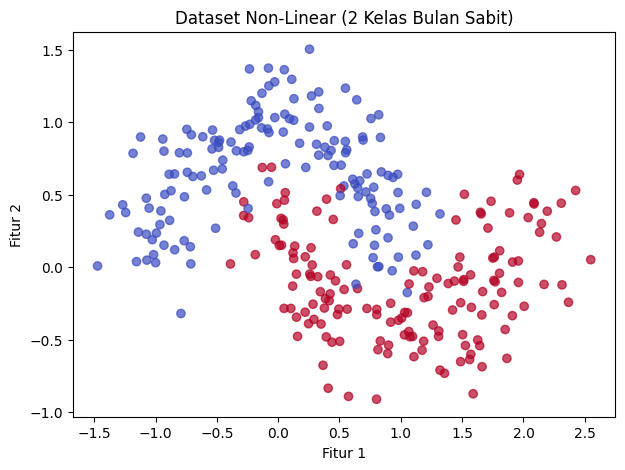

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.show()


**Interpretasi:**  
Dua kelas pada dataset terlihat saling melengkung dan bertautan. Karena pola pemisahnya tidak linear, neural network dengan activation function non-linear lebih sesuai digunakan dibandingkan model yang hanya menghasilkan batas keputusan berupa garis lurus.


## Langkah 2 — Bangun & Latih Neural Network Sederhana

Arsitektur yang digunakan:
- Hidden layer 1: 16 neuron, ReLU
- Hidden layer 2: 8 neuron, ReLU
- Output layer: 1 neuron, Sigmoid


In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_tr, y_tr,
    epochs=30,
    validation_split=0.2,
    verbose=0
)

print("Training selesai.")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Training selesai.


## Langkah 3 — Evaluasi & Visualisasi Kurva Belajar


Akurasi pada data uji: 0.900


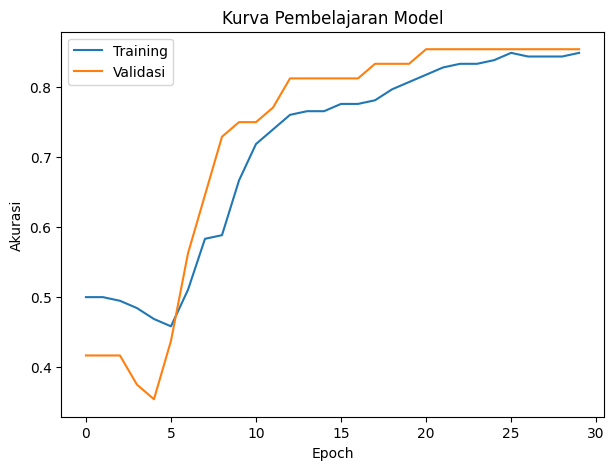

In [3]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.figure(figsize=(7, 5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.title('Kurva Pembelajaran Model')
plt.legend()
plt.show()


**Interpretasi:**  
Perhatikan kurva training dan validasi setelah notebook dijalankan. Jika keduanya meningkat dan nilainya relatif berdekatan, model belajar dengan baik. Jika akurasi training terus naik tetapi akurasi validasi tertinggal atau menurun jauh, hal tersebut dapat menjadi indikasi overfitting.


## Langkah 4 — Siapkan Dataset Ulasan Produk

Dataset berikut berisi 40 ulasan sintetis berbahasa Indonesia dengan label:
- `1` = positif
- `0` = negatif


In [4]:
ulasan = [
    'Barangnya bagus banget, pengiriman cepat',
    'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi',
    'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas',
    'Buruk sekali, tidak sesuai ekspektasi',
    'Produknya sangat bagus dan bermanfaat',
    'Pengiriman sangat lama dan mengecewakan',
    'Kualitas produk memuaskan',
    'Barang cacat dan tidak bisa digunakan',
    'Pelayanan ramah dan cepat',
    'Produk tidak sesuai dengan foto',
    'Harga murah tetapi kualitas bagus',
    'Saya menyesal membeli produk ini',
    'Barang sampai dengan aman dan rapi',
    'Kualitas sangat buruk',
    'Produk bekerja dengan baik',
    'Paket datang terlambat',
    'Sangat suka dengan produknya',
    'Barang mudah rusak',
    'Penjual responsif dan ramah',
    'Produk mengecewakan',
    'Hasilnya sesuai harapan',
    'Tidak direkomendasikan',
    'Barang original dan berkualitas',
    'Pelayanan sangat buruk',
    'Pengemasan sangat rapi',
    'Produk tidak berfungsi',
    'Harga sesuai dengan kualitas',
    'Saya tidak puas dengan barangnya',
    'Barang bagus dan cepat sampai',
    'Deskripsi produk tidak sesuai',
    'Kualitasnya sangat memuaskan',
    'Barang rusak setelah digunakan',
    'Sangat recommended untuk dibeli',
    'Pengiriman mengecewakan dan lambat',
    'Produk sesuai pesanan',
    'Kualitas jauh dari harapan',
    'Saya puas dengan pelayanan penjual',
    'Barang tidak sesuai ekspektasi'
]

label = [
    1,0,1,0,1,0,1,0,1,0,
    1,0,1,0,1,0,1,0,1,0,
    1,0,1,0,1,0,1,0,1,0,
    1,0,1,0,1,0,1,0,1,0
]

print('Jumlah ulasan:', len(ulasan))
print('Jumlah label:', len(label))


Jumlah ulasan: 40
Jumlah label: 40


## Langkah 5 — Ubah Teks Menjadi TF-IDF

TF-IDF memberi bobot lebih tinggi pada kata yang lebih khas/bermakna dalam dokumen dan bobot lebih rendah pada kata yang terlalu umum.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('10 kata pertama:')
print(tfidf.get_feature_names_out()[:10])


Jumlah kata unik: 71
10 kata pertama:
['akan' 'aman' 'bagus' 'baik' 'banget' 'barang' 'barangnya' 'bekerja'
 'beli' 'berfungsi']


## Langkah 6 — Latih Model Klasifikasi Sentimen & Evaluasi


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
    X_text, label, test_size=0.2, random_state=42
)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')


Akurasi model sentimen: 0.750


In [7]:
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))

print('Kalimat:', kalimat_baru[0])
print('Prediksi:', 'Positif' if pred[0] == 1 else 'Negatif')


Kalimat: Pelayanan sangat memuaskan dan ramah
Prediksi: Positif


## Kesimpulan

Pada Pertemuan 13, saya mempelajari konsep dasar **Artificial Neural Network (ANN)** untuk klasifikasi data non-linear serta pengolahan teks sederhana menggunakan **TF-IDF** untuk analisis sentimen. Neural network memanfaatkan hidden layer dan activation function non-linear untuk mempelajari pola yang tidak dapat dipisahkan dengan garis lurus. Pada bagian NLP, TF-IDF mengubah teks menjadi representasi numerik yang kemudian digunakan oleh Logistic Regression untuk klasifikasi sentimen positif dan negatif.

Temuan utama menunjukkan bahwa ANN dapat mempelajari pola non-linear, sedangkan TF-IDF merupakan pendekatan awal yang sederhana, cepat, dan mudah dipahami untuk klasifikasi teks.

**Keterbatasan:** dataset yang digunakan masih kecil dan sintetis, serta preprocessing teks masih sederhana. Pengembangan selanjutnya dapat menggunakan dataset ulasan yang lebih besar, menambahkan preprocessing bahasa Indonesia, dan membandingkan TF-IDF dengan embedding atau model NLP yang lebih modern.